In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

import sys, os
sys.path.append(os.path.abspath("../src"))

from binomial_model import price_option_tree, price_option_tree_no_volatility
from visualization import plot_binomial_trees
from black_scholes_merton import price_option_bsm

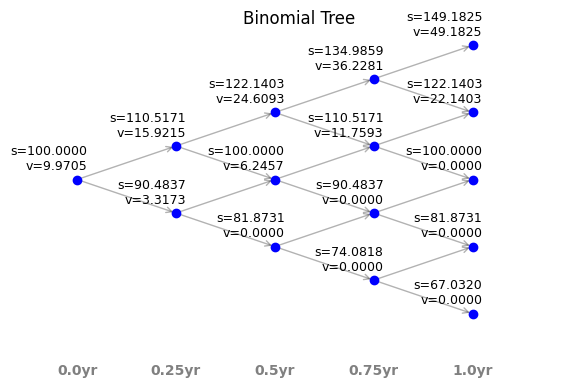

In [2]:
price, stocks, options, timeline = price_option_tree(option_type="call", exercise_style="American", s=100, k=100,
                                                sigma=0.2, T=1, N=4, r=0.05, return_tree=True)

plot_binomial_trees(stocks, options, timeline)

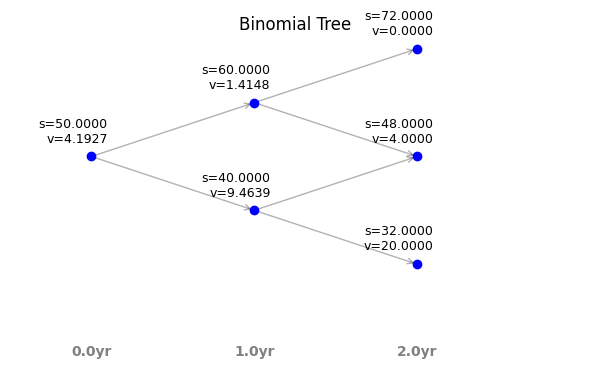

In [3]:
#figure 13.7
price, stocks, options, timeline = price_option_tree_no_volatility(option_type='put',exercise_style='European', s=50, k=52, 
                                                              up=20, down=20, T=2, N=2, r=0.05, return_tree=True)

plot_binomial_trees(stocks, options, timeline)

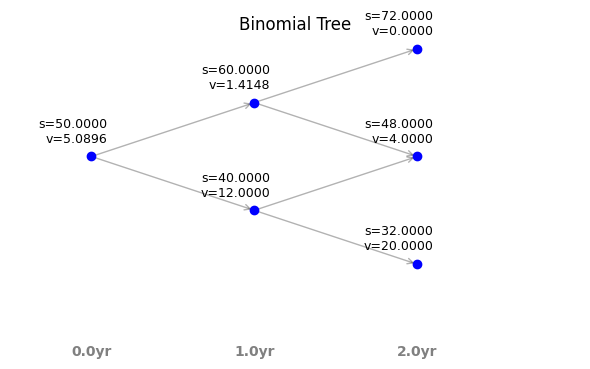

In [4]:
#figure 13.8
price, stocks, options, timeline = price_option_tree_no_volatility(option_type='put',exercise_style='American', s=50, k=52, 
                                                                     up=20, down=20, T=2, N=2, r=0.05, return_tree=True)

plot_binomial_trees(stocks, options, timeline)

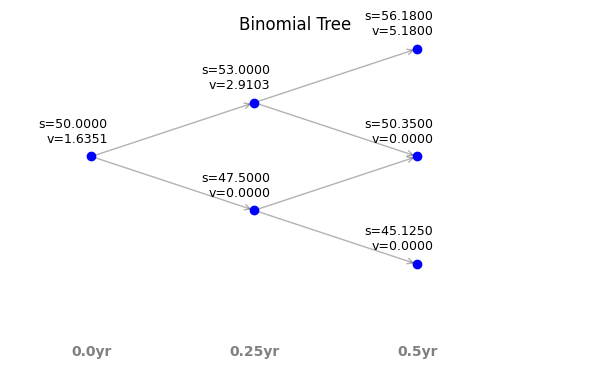

In [5]:
# practice 13.7
price, stocks, options, timeline =  price_option_tree_no_volatility(option_type='call',exercise_style='European',s=50, k=51, 
                                                                      up=6, down=5, T=0.5, N=2, r=0.05, return_tree=True)

plot_binomial_trees(stocks, options, timeline)

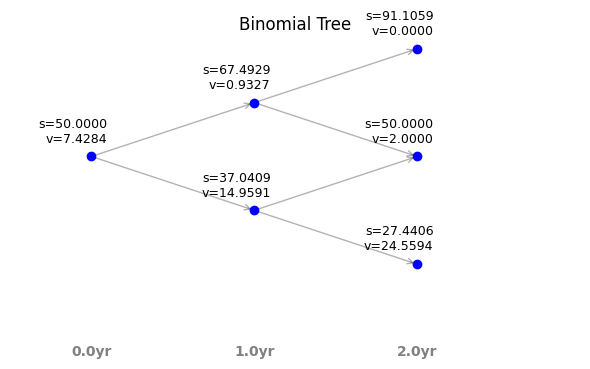

In [6]:

option_value, stocks, options, timeline = price_option_tree(option_type='put',exercise_style='American', s=50, k=52, 
                                                       sigma=0.3, T=2, N=2, r=0.05, return_tree=True)

plot_binomial_trees(stocks, options, timeline)

In [7]:
# Example 15.6
print(price_option_bsm(option_type='call', exercise_style='European', s=42, k=40, T=0.5, r=0.1, q=0, sigma=0.2))
print(price_option_bsm(option_type='put', exercise_style='European', s=42, k=40, T=0.5, r=0.1, q=0, sigma=0.2))

4.759422392871532
0.8085993729000922


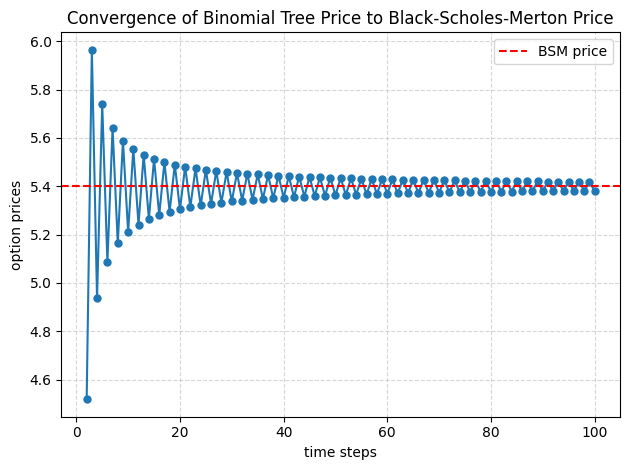

In [8]:
prices = []
time_steps = np.arange(2,101)
BSM_price = price_option_bsm(option_type='put', exercise_style='European', s=50, k=50, T=1, r=0.1, q=0, sigma=0.4)


for N in time_steps:
    price = price_option_tree(option_type="put", exercise_style="European", s=50, k=50,
                                                sigma=0.4, T=1, N=N, r=0.1, return_tree=False)
    prices.append(price)

plt.plot(time_steps, prices, marker='o', linestyle='-', ms=5)
plt.axhline(y=BSM_price, color='r', linestyle='--', label='BSM price')
plt.ylabel('option prices')
plt.xlabel('time steps')
plt.title('Convergence of Binomial Tree Price to Black-Scholes-Merton Price')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()